# Artificial Neural Network - Video Game Success Prediction

#### Import Libraries


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.callbacks import ModelCheckpoint

#### Import Data

In [2]:
data_for_model = pd.read_csv("data/ann-game-data.csv")

#### Drop any redundant columns

In [3]:
data_for_model.drop("player_id", axis = 1, inplace = True)

#### Split Input Variables & Output Variable

In [4]:
X = data_for_model.drop(["success"], axis = 1)
y = data_for_model["success"]

#### Split out Training & Test sets

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

#### Deal with Categorical Variables

In [7]:
categorical_vars = ["clan"]

one_hot_encoder = OneHotEncoder(sparse_output = False, drop = "first")

X_train_encoded = one_hot_encoder.fit_transform(X_train[categorical_vars])
X_test_encoded = one_hot_encoder.transform(X_test[categorical_vars])

encoder_feature_names = one_hot_encoder.get_feature_names_out(categorical_vars)

X_train_encoded = pd.DataFrame(X_train_encoded, columns = encoder_feature_names)
X_train = pd.concat([X_train.reset_index(drop=True), X_train_encoded.reset_index(drop=True)], axis = 1)
X_train.drop(categorical_vars, axis = 1, inplace = True)

X_test_encoded = pd.DataFrame(X_test_encoded, columns = encoder_feature_names)
X_test = pd.concat([X_test.reset_index(drop=True), X_test_encoded.reset_index(drop=True)], axis = 1)
X_test.drop(categorical_vars, axis = 1, inplace = True)

#### Feature Scaling

In [8]:
scale_norm = MinMaxScaler()
X_train = pd.DataFrame(scale_norm.fit_transform(X_train), columns = X_train.columns)
X_test = pd.DataFrame(scale_norm.transform(X_test), columns = X_test.columns)

## Network Architecture

#### Network architecture

In [9]:
model = Sequential()

model.add(Dense(units = 32, input_dim = X_train.shape[1]))
model.add(Activation('relu'))

model.add(Dense(units = 32))
model.add(Activation('relu'))

model.add(Dense(units = 1))
model.add(Activation('sigmoid'))

/opt/anaconda3/envs/dsi-deep-learning/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Compile network

In [10]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

#### View network architecture

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345 (5.25 KB)

 Trainable params: 1,345 (5.25 KB)

 Non-trainable params: 0 (0.00 B)

## Train Our Network

#### Training parameters

In [12]:
num_epochs = 50
batch_size = 32
model_filename = 'models/video_game_ann.h5'

#### Callbacks

In [13]:
save_best_model = ModelCheckpoint(filepath = model_filename,
                                 monitor = 'val_accuracy',
                                 mode = 'max',
                                 verbose = 1,
                                 save_best_only = True)

#### Train the network

In [14]:
history = model.fit(x = X_train.values,
                   y = y_train,
                   validation_data = (X_test, y_test),
                   batch_size = batch_size,
                   epochs = num_epochs,
                   callbacks = [save_best_model])

Epoch 1/50
  1/100 ━━━━━━━━━━━━━━━━━━━━ 44s 452ms/step - accuracy: 0.6250 - loss: 0.6800
Epoch 1: val_accuracy improved from None to 0.85750, saving model to models/video_game_ann.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7588 - loss: 0.5698 - val_accuracy: 0.8575 - val_loss: 0.4124
Epoch 2/50
  1/100 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8438 - loss: 0.4505
Epoch 2: val_accuracy improved from 0.85750 to 0.91875, saving model to models/video_game_ann.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 527us/step - accuracy: 0.8875 - loss: 0.3164 - val_accuracy: 0.9187 - val_loss: 0.2347
Epoch 3/50
  1/100 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8750 - loss: 0.3106
Epoch 3: val_accuracy did not improve from 0.91875
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step - accuracy: 0.9000 - loss: 0.2327 - val_accuracy: 0.9100 - val_loss: 0.2114
Epoch 4/50
  1/100 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9062 - loss: 0.2120
Epoch 4: val_accuracy did not improve from 0.91875
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 502us/step - accuracy: 0.9078 - loss: 0.2156 - val_accuracy: 0.9162 - val_loss: 0.1902
Epoch 5/50
  1/100 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9375 - loss: 0.1689
Epoch 5: val_accuracy improved from 0.91875 to 0.92250, saving model to models/video_game_ann.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 546us/step - accuracy: 0.9106 - loss: 0.2033 - val_accuracy: 0.9225 - val_loss: 0.1846
Epoch 6/50
  1/100 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9062 - loss: 0.2254
Epoch 6: val_accuracy did not improve from 0.92250
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 492us/step - accuracy: 0.9144 - loss: 0.1978 - val_accuracy: 0.9162 - val_loss: 0.1850
Epoch 7/50
  1/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9688 - loss: 0.0924
Epoch 7: val_accuracy improved from 0.92250 to 0.92875, saving model to models/video_game_ann.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 527us/step - accuracy: 0.9175 - loss: 0.1910 - val_accuracy: 0.9287 - val_loss: 0.1754
Epoch 8/50
  1/100 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8438 - loss: 0.2926
Epoch 8: val_accuracy improved from 0.92875 to 0.93375, saving model to models/video_game_ann.h5


...

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 519us/step - accuracy: 0.9266 - loss: 0.1670 - val_accuracy: 0.9438 - val_loss: 0.1537
Epoch 14/50
  1/100 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8750 - loss: 0.2497
Epoch 14: val_accuracy did not improve from 0.94375
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 453us/step - accuracy: 0.9353 - loss: 0.1615 - val_accuracy: 0.9413 - val_loss: 0.1476
Epoch 15/50
  1/100 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9688 - loss: 0.1033
Epoch 15: val_accuracy did not improve from 0.94375
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 454us/step - accuracy: 0.9334 - loss: 0.1553 - val_accuracy: 0.9362 - val_loss: 0.1448
Epoch 16/50
  1/100 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8750 - loss: 0.2556
Epoch 16: val_accuracy did not improve from 0.94375
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 456us/step - accuracy: 0.9353 - loss: 0.1513 - val_accuracy: 0.9187 - val_loss: 0.1552
Epoch 17/50
  1/100 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9688 - loss: 0.0937
Epoch 17: val_accura

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 505us/step - accuracy: 0.9337 - loss: 0.1495 - val_accuracy: 0.9450 - val_loss: 0.1391
Epoch 18/50
  1/100 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0948
Epoch 18: val_accuracy improved from 0.94500 to 0.94750, saving model to models/video_game_ann.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 500us/step - accuracy: 0.9378 - loss: 0.1427 - val_accuracy: 0.9475 - val_loss: 0.1366
Epoch 19/50
  1/100 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9688 - loss: 0.0862
Epoch 19: val_accuracy did not improve from 0.94750
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 467us/step - accuracy: 0.9428 - loss: 0.1400 - val_accuracy: 0.9450 - val_loss: 0.1288
Epoch 20/50
  1/100 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9062 - loss: 0.1938
Epoch 20: val_accuracy improved from 0.94750 to 0.95000, saving model to models/video_game_ann.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 500us/step - accuracy: 0.9431 - loss: 0.1365 - val_accuracy: 0.9500 - val_loss: 0.1265
Epoch 21/50
  1/100 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8750 - loss: 0.2321
Epoch 21: val_accuracy did not improve from 0.95000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step - accuracy: 0.9450 - loss: 0.1331 - val_accuracy: 0.9375 - val_loss: 0.1320
Epoch 22/50
  1/100 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9375 - loss: 0.1213
Epoch 22: val_accuracy did not improve from 0.95000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 442us/step - accuracy: 0.9450 - loss: 0.1276 - val_accuracy: 0.9463 - val_loss: 0.1205
Epoch 23/50
  1/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9062 - loss: 0.2352
Epoch 23: val_accuracy improved from 0.95000 to 0.95750, saving model to models/video_game_ann.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 471us/step - accuracy: 0.9475 - loss: 0.1233 - val_accuracy: 0.9575 - val_loss: 0.1162
Epoch 24/50
  1/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9688 - loss: 0.0889
Epoch 24: val_accuracy did not improve from 0.95750
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 427us/step - accuracy: 0.9472 - loss: 0.1211 - val_accuracy: 0.9550 - val_loss: 0.1147
Epoch 25/50
  1/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9688 - loss: 0.1174
Epoch 25: val_accuracy did not improve from 0.95750
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 421us/step - accuracy: 0.9453 - loss: 0.1217 - val_accuracy: 0.9488 - val_loss: 0.1121
Epoch 26/50
  1/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9688 - loss: 0.0757
Epoch 26: val_accuracy did not improve from 0.95750
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 415us/step - accuracy: 0.9478 - loss: 0.1177 - val_accuracy: 0.9475 - val_loss: 0.1107
Epoch 27/50
  1/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9688 - loss: 0.0918
Epoch 27: val_accura

## Visualise Training & Validation Performance

In [16]:
import matplotlib.pyplot as plt

#### Plot metrics by epoch

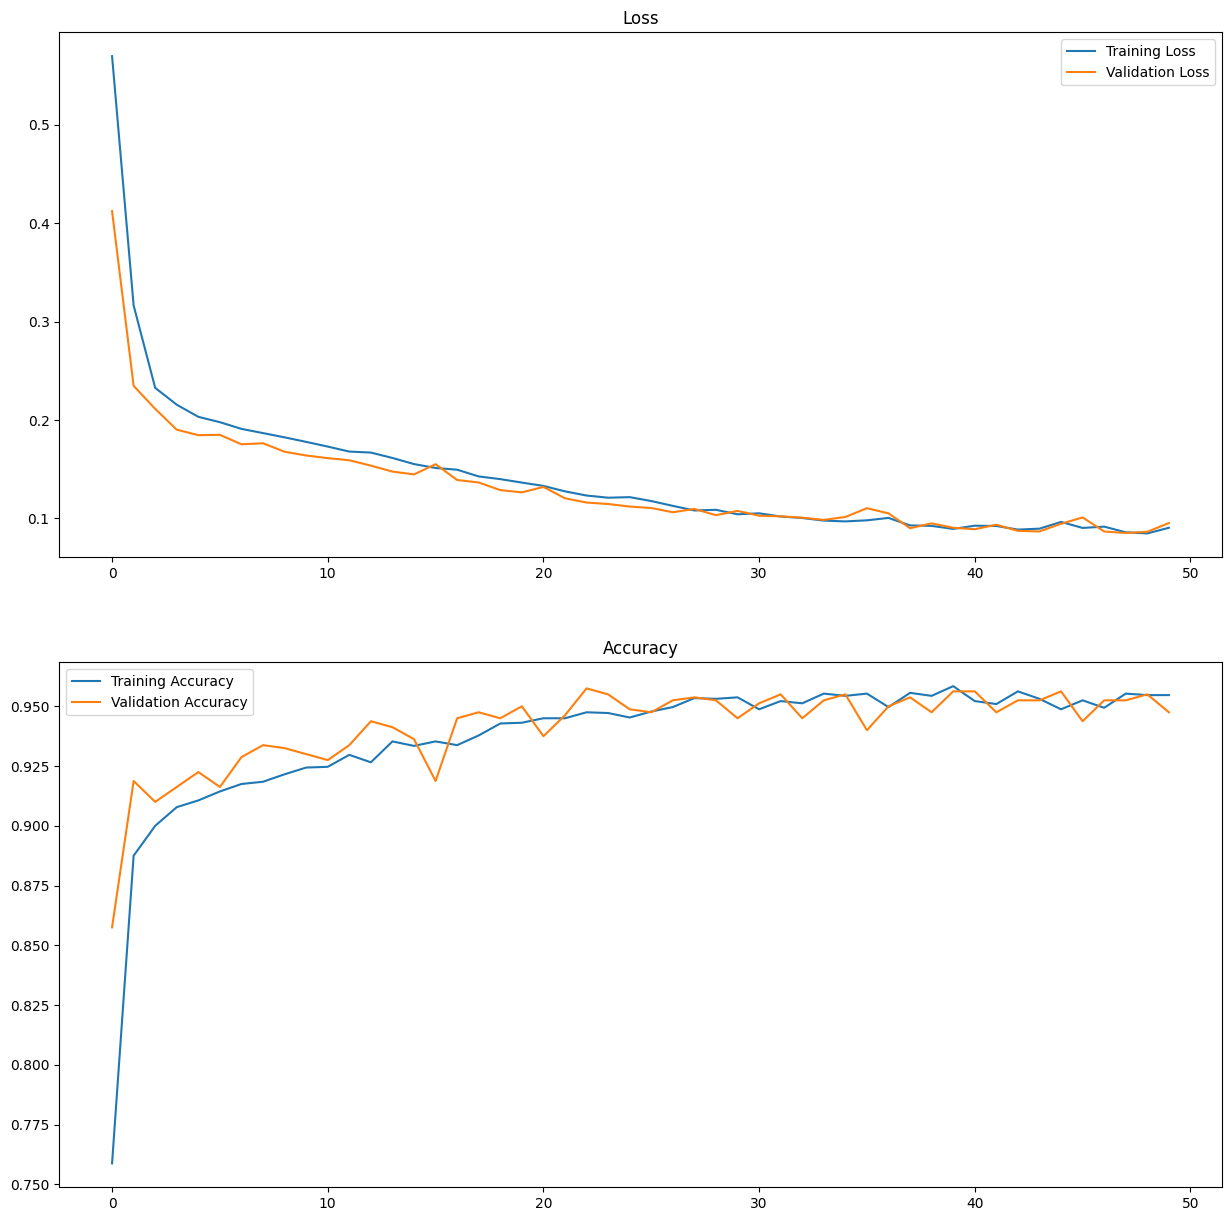

In [17]:
fig, ax = plt.subplots(2, 1, figsize=(15,15))
ax[0].set_title('Loss')
ax[0].plot(history.epoch, history.history["loss"], label="Training Loss")
ax[0].plot(history.epoch, history.history["val_loss"], label="Validation Loss")
ax[1].set_title('Accuracy')
ax[1].plot(history.epoch, history.history["accuracy"], label="Training Accuracy")
ax[1].plot(history.epoch, history.history["val_accuracy"], label="Validation Accuracy")
ax[0].legend()
ax[1].legend()
plt.show()

#### Get best epoch performance for validation accuracy

In [18]:
max(history.history['val_accuracy'])

0.9574999809265137

## Make Predictions On New Data

#### Import packages

In [19]:
from tensorflow.keras.models import load_model

#### Load model

In [20]:
model = load_model(model_filename)

#### Create new data

In [24]:
list(X_train)

player_a = [[9, 30, 6, 11, 62, 0, 1]]
player_a = scale_norm.transform(player_a)

player_b = [[11, 27, 0, 9, 59, 0, 0]]
player_b = scale_norm.transform(player_b)

/opt/anaconda3/envs/dsi-deep-learning/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dsi-deep-learning/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


#### Make our prediction

In [26]:
prediction = model.predict(player_a)
print(prediction)

prediction = model.predict(player_b)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
[[0.53904855]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
[[0.928704]]


In [27]:
prediction_class = (prediction >= 0.5) * 1
print(prediction_class)

[[1]]
